## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.
# I completed this version without generative AI.

1. What is the difference between regression and classification?  
Regression predicts a numerical value. Classification predicts a category.

2. What is a confusion table? What does it help us understand about a model's performance?  
A confusion table is a table which compares the true labels with the predicted labels and counts the number of correct and incorrect predictions for each class, indicating which classes the model confuses and what types of errors it makes.

3. What does the SSE quantify about a particular model?  
SSE is a measure of the total of the squared differences between the actual and the predicted numerical values, if the SSE is lower then the predictions are more accurate for the same dataset, and the process of squaring causes larger errors to count more.

4. What are overfitting and underfitting?  
Overfitting is when a model learns the noise present in the training data rather than the actual patterns, which causes it to perform well on the training data but badly on new data. Underfitting is when the model is too simple to capture the important patterns and therefore performs poorly on both the training and new data.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?  
The training and testing split involves using data that has not been seen before to determine whether a model is generalizing rather than going off the training examples. The model should be selected on the basis of higher accuracy or lower SSE when evaluated on the held out data because that leads to better performance on future observations. You should also validate to make sure you are not overfitting.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.  
Class labels are easy to understand and immediately useful, but they do not show uncertainty since a prediction that is only slightly in favour appears no different from one that is very confident. Probability distributions do reveal the uncertainty and allow you to set decision thresholds according to the costs of different types of errors. Yet they are more complicated, require a decision rule if only a single label is needed, and can be misleading if the probabilities are not well calibrated.

Data Head:
     voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1

Summary Statistics:
           voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000

Class Distribution:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Optimal k selected: 2

Confusion Matrix:
 [[17  0 18  2  0]
 [ 0 25  4  4  0]
 [ 8  3 16  2  3]
 [12  5 10  7  2]
 [ 8  2 12  6  3]]


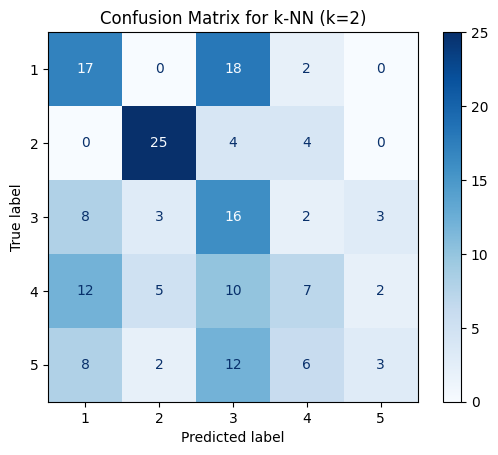


Test Set Accuracy: 40.24%


In [4]:
# Q2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# load the dataset
df = pd.read_csv("land_mines.csv")

# eda of the features and the target label (mine_type)
# 338 mines, features are all scaled 0 to 1 (voltage ranges only 0.2 to 1, mean 0.43)
# the 5 mine types are nearly balanced (65 to 71 each), so always guessing one type gets ~21%
print("Data Head:\n", df.head())
print("\nSummary Statistics:\n", df.describe())
print("\nClass Distribution:\n", df["mine_type"].value_counts())

# split the sample 50/50 into training and test sets
# an even split is used since the data is small, so the test set still has enough of each type
# (31 to 37 per type in the test set)
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# build the k-NN classifier and select k using test accuracy
# small k overfits (high train accuracy, lower test accuracy), large k oversmooths
# so the k with the highest test accuracy is the best balance of the two
train_acc = []
test_acc = []
k_values = range(1, 20)

# fit a model for each k and record train and test accuracy
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  train_acc.append(knn.score(X_train, y_train))
  test_acc.append(knn.score(X_test, y_test))

# pick the k with the highest test accuracy
# k = 2 is selected with a test accuracy of about 40.2%
# test accuracy is low and noisy across k (about 30% to 40%), so the choice of k is not very strong
optimal_k = k_values[np.argmax(test_acc)]
print(f"\nOptimal k selected: {optimal_k}")

# train the final model with optimal k
best_knn = KNeighborsClassifier(n_neighbors=optimal_k)
best_knn.fit(X_train, y_train)

# confusion table of predicted vs actual mine type on the test set
# rows are the actual class and columns are the predicted class
y_pred = best_knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix for k-NN (k={optimal_k})")
plt.show()

# overall accuracy on the test set
# 40.2% is about double random guessing (20%) but still poor, and k was picked on this same test set so it is slightly optimistic
# type 2 is the most accurate (about 76% of actual type 2 predicted correctly), type 3 is about 50% and type 1 about 46%
# types 4 and 5 are the worst (about 19% and 10%), they get mislabeled as types 1 and 3 most often
# type 1 and type 3 are also confused with each other (18 type 1 mines predicted as type 3)
accuracy = np.mean(y_pred == y_test)
print(f"\nTest Set Accuracy: {accuracy * 100:.2f}%")

# in practice, a predicted type is only reliable for some types
# a type 2 prediction is right about 71% of the time, but predictions of types 1, 3, 4 and 5 are right only about 27% to 38% of the time
# so the model should not be used alone to decide what kind of mine something is
# use it to flag likely type 2 mines, and treat predictions of types 1, 3, 4 and 5 as unconfirmed and check them with other information
# types 4 and 5 are rarely predicted correctly, so a prediction that is not type 2 should not be taken as evidence against type 4 or 5
# which errors matter most depends on what each mine type means, which should be decided with the demining experts

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]